**Setup kaggle**

In [ ]:
import os
import json

# Kaggle credentials
kaggle_username = ""
kaggle_key      = ""

# Create kaggle.json
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump({"username": kaggle_username, "key": kaggle_key}, f)
os.chmod('/root/.kaggle/kaggle.json', 0o600)

!pip install -q kaggle
print("✅ Kaggle ready!")


✅ Kaggle ready!


**Download & Unzip Dataset**

In [ ]:
!kaggle datasets download -d abdallahalidev/plantvillage-dataset
!unzip -q plantvillage-dataset.zip -d /content/PlantVillage
print("✅ Dataset ready!")


Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.04G/2.04G [00:13<00:00, 158MB/s] 

✅ Dataset ready!


**Verify Dataset**

In [ ]:
import os

DATASET_PATH = '/content/PlantVillage/plantvillage dataset/color'

folders = os.listdir(DATASET_PATH)
print(f"✅ Total classes: {len(folders)}")
print(f"✅ Dataset path : {DATASET_PATH}")


✅ Total classes: 38
✅ Dataset path : /content/PlantVillage/plantvillage dataset/color


**Mount Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Drive mounted!")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted!


**Check GPU**

In [ ]:
import tensorflow as tf
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))


TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


**Imports & Config**

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.layers import (
    Input, DepthwiseConv2D, Conv2D, MaxPooling2D,
    GlobalAveragePooling2D, Dense, BatchNormalization,
    ReLU, Dropout, Concatenate
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from sklearn.metrics import classification_report, confusion_matrix

# ── Configuration ──────────────────────────────────────
DATASET_PATH = '/content/PlantVillage/plantvillage dataset/color'
IMG_SIZE     = (128, 128)
BATCH_SIZE   = 64
EPOCHS       = 30
NUM_CLASSES  = 38
LR           = 0.001
DROPOUT      = 0.25
SAVE_PATH    = '/content/drive/MyDrive/EnConv_best.keras'

print("✅ All imports done!")
print(f"✅ Classes : {NUM_CLASSES}")
print(f"✅ Epochs  : {EPOCHS}")
print(f"✅ Batch   : {BATCH_SIZE}")


✅ All imports done!
✅ Classes : 38
✅ Epochs  : 30
✅ Batch   : 64


**Data Generators**

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_gen = val_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

print(f"✅ Training samples  : {train_gen.samples}")
print(f"✅ Validation samples: {val_gen.samples}")
print(f"✅ Classes found     : {len(train_gen.class_indices)}")


Found 43456 images belonging to 38 classes.
Found 10849 images belonging to 38 classes.
✅ Training samples  : 43456
✅ Validation samples: 10849
✅ Classes found     : 38


**Build EnConv Model**

In [ ]:
def depthwise_sep_block(x, pw_filters, pool=True):
    x = DepthwiseConv2D(kernel_size=3, padding='same',
                        depthwise_initializer='he_normal')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = Conv2D(pw_filters, kernel_size=1, padding='same',
               kernel_initializer='he_normal')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    if pool:
        x = MaxPooling2D(pool_size=2, strides=2)(x)
    return x

def build_EnConv(num_classes=38, dropout=0.25):
    # ✅ Input matches IMG_SIZE exactly
    inputs = Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

    x    = depthwise_sep_block(inputs, pw_filters=32)
    x    = depthwise_sep_block(x,      pw_filters=64)
    gap1 = GlobalAveragePooling2D()(x)

    x    = depthwise_sep_block(x,      pw_filters=128)
    x    = depthwise_sep_block(x,      pw_filters=256)
    x    = depthwise_sep_block(x,      pw_filters=512)
    gap2 = GlobalAveragePooling2D()(x)

    concat = Concatenate()([gap1, gap2])
    x      = Dense(769, activation='relu',
                   kernel_initializer='he_normal')(concat)
    x      = Dropout(dropout)(x)
    out    = Dense(num_classes, activation='softmax')(x)

    return Model(inputs, out, name='EnConv')

# Rebuild model fresh
model = build_EnConv(num_classes=NUM_CLASSES, dropout=DROPOUT)
model.compile(
    optimizer=Adam(learning_rate=LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
# Confirm input shape
print(f"✅ Model input shape : {model.input_shape}")
print(f"✅ Generator shape   : {train_gen.image_shape}")
print(f"✅ Parameters        : {model.count_params():,}")

✅ Model input shape : (None, 128, 128, 3)
✅ Generator shape   : (128, 128, 3)
✅ Parameters        : 658,871


**Train Model**

In [ ]:
callbacks = [
    ModelCheckpoint(
        SAVE_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=15,
        restore_best_weights=True,
        verbose=1
    )
]

print("🚀 Training started... (~2 hrs on T4 GPU)")
print("   Model saves to Drive automatically\n")

history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=callbacks,
    verbose=1
)

print("\n🎯 Training complete!")

🚀 Training started... (~2 hrs on T4 GPU)
   Model saves to Drive automatically

Epoch 1/30
679/679 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.4819 - loss: 1.9063
Epoch 1: val_accuracy improved from None to 0.60900, saving model to /content/drive/MyDrive/EnConv_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/EnConv_best.keras
679/679 ━━━━━━━━━━━━━━━━━━━━ 274s 369ms/step - accuracy: 0.6106 - loss: 1.3494 - val_accuracy: 0.6090 - val_loss: 1.4127 - learning_rate: 0.0010
Epoch 2/30
679/679 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step - accuracy: 0.7631 - loss: 0.7478
Epoch 2: val_accuracy did not improve from 0.60900
679/679 ━━━━━━━━━━━━━━━━━━━━ 242s 356ms/step - accuracy: 0.7803 - loss: 0.6913 - val_accuracy: 0.4853 - val_loss: 2.5678 - learning_rate: 0.0010
Epoch 3/30
679/679 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 0.8331 - loss: 0.5235
Epoch 3: val_accuracy did not improve from 0.60900
679/679 ━━━━━━━━━━━━━━━━━━━━ 237s 349ms/step - accuracy: 0.8413 - loss: 0.4983

In [ ]:
train_acc = max(history.history['accuracy']) * 100
val_acc   = max(history.history['val_accuracy']) * 100

print(f"Training Accuracy  : {train_acc:.2f}%")
print(f"Validation Accuracy: {val_acc:.2f}%")
print(f"Total Epochs Run   : {len(history.history['accuracy'])}")

Training Accuracy  : 98.39%
Validation Accuracy: 90.52%
Total Epochs Run   : 30


**Plot Accuracy & Loss**

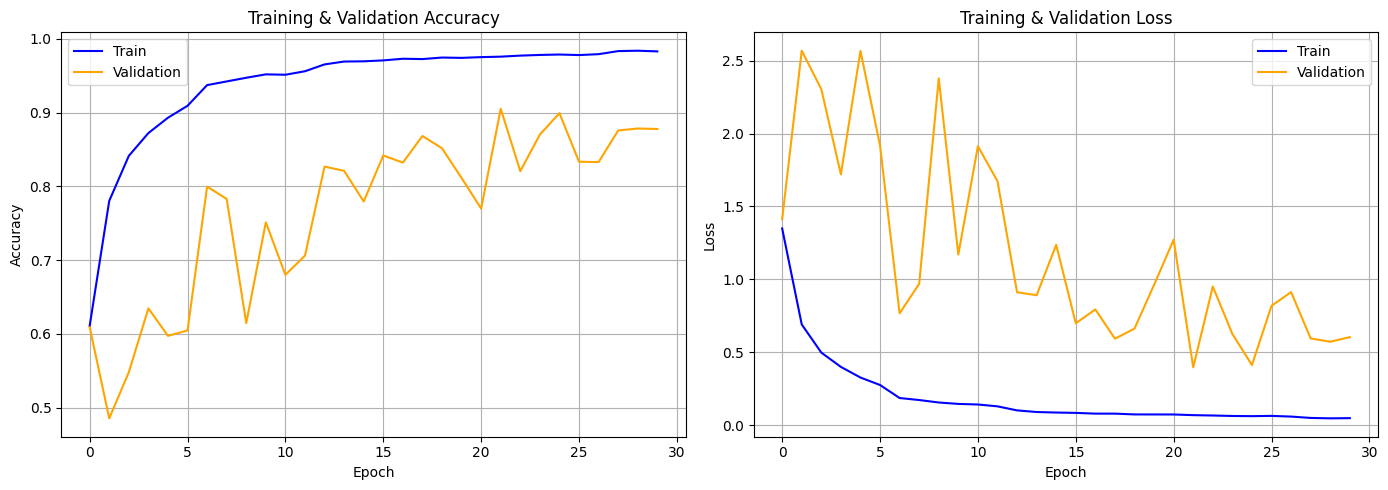

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],
             label='Train', color='blue')
axes[0].plot(history.history['val_accuracy'],
             label='Validation', color='orange')
axes[0].set_title('Training & Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(history.history['loss'],
             label='Train', color='blue')
axes[1].plot(history.history['val_loss'],
             label='Validation', color='orange')
axes[1].set_title('Training & Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/EnConv_curves.png', dpi=150)
plt.show()

**Evaluate Model**

In [ ]:
# Load best saved weights
model = tf.keras.models.load_model(SAVE_PATH)

# Get predictions
val_gen.reset()
y_pred_probs = model.predict(val_gen, verbose=1)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = val_gen.classes
class_names  = list(val_gen.class_indices.keys())

# Overall accuracy
acc = np.mean(y_pred == y_true) * 100
print(f"\n🎯 Final Accuracy: {acc:.2f}%")

# Detailed report
print("\n=== Classification Report ===")
print(classification_report(
    y_true, y_pred,
    target_names=class_names
))

170/170 ━━━━━━━━━━━━━━━━━━━━ 17s 82ms/step

🎯 Final Accuracy: 90.52%

=== Classification Report ===
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.99      0.80      0.89       126
                                 Apple___Black_rot       0.81      0.95      0.87       124
                          Apple___Cedar_apple_rust       1.00      0.89      0.94        55
                                   Apple___healthy       0.89      0.92      0.91       329
                               Blueberry___healthy       1.00      0.91      0.95       300
          Cherry_(including_sour)___Powdery_mildew       0.99      0.93      0.96       210
                 Cherry_(including_sour)___healthy       0.79      0.98      0.87       170
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.75      0.93      0.83       102
                       Corn_(maize)___Common_rust_       1.00      1.00

**Confusion Matrix**

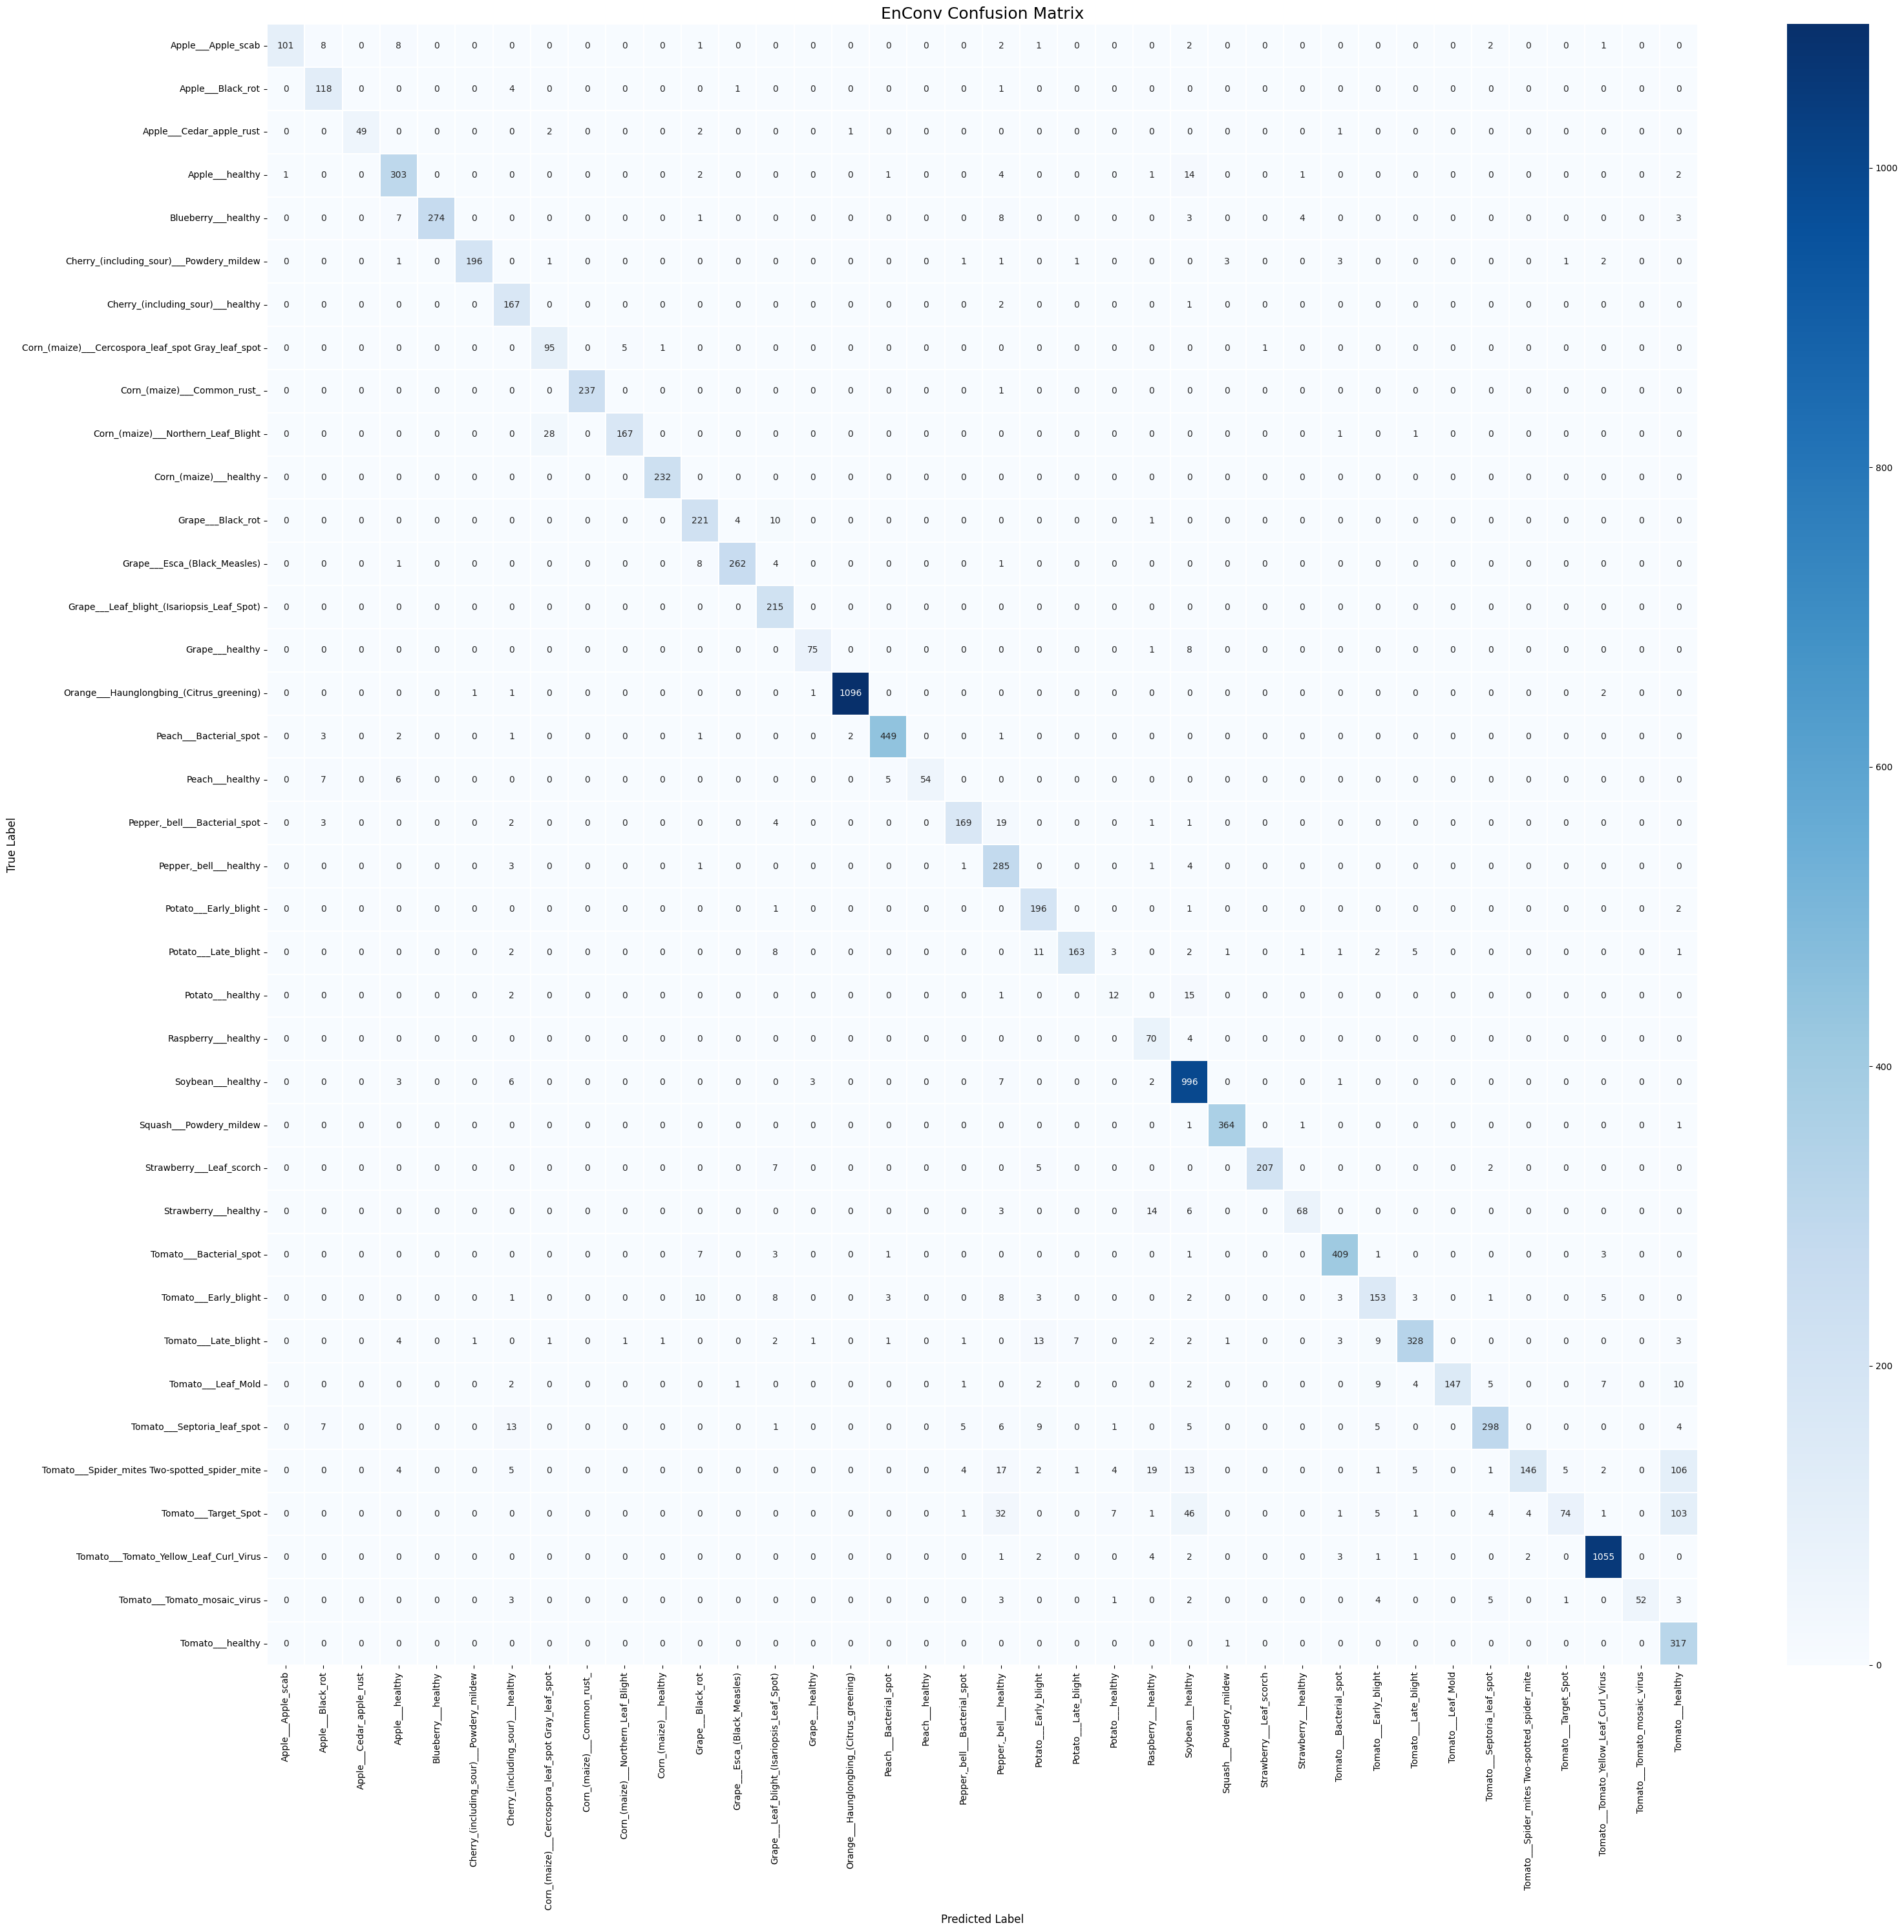

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(32, 30))
sns.heatmap(
    cm, annot=True, fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.3
)
plt.title('EnConv Confusion Matrix', fontsize=18)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/EnConv_confusion.png', dpi=120)
plt.show()

**Test on Single Image**

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


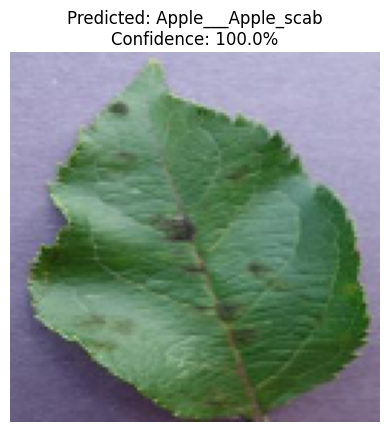

Disease : Apple___Apple_scab
Confidence: 99.97%


In [ ]:
from tensorflow.keras.preprocessing import image as keras_image

def predict_leaf(img_path):
    img  = keras_image.load_img(img_path, target_size=(128, 128))
    arr  = keras_image.img_to_array(img) / 255.0
    arr  = np.expand_dims(arr, axis=0)
    pred = model.predict(arr)
    idx  = np.argmax(pred)

    plt.imshow(img)
    plt.axis('off')
    plt.title(
        f"Predicted: {class_names[idx]}\n"
        f"Confidence: {pred[0][idx]*100:.1f}%",
        fontsize=12
    )
    plt.show()
    print(f"Disease : {class_names[idx]}")
    print(f"Confidence: {pred[0][idx]*100:.2f}%")

# Usage — put any leaf image path here:
predict_leaf('/content/PlantVillage/plantvillage dataset/color/Apple___Apple_scab/00075aa8-d81a-4184-8541-b692b78d398a___FREC_Scab 3335.JPG')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


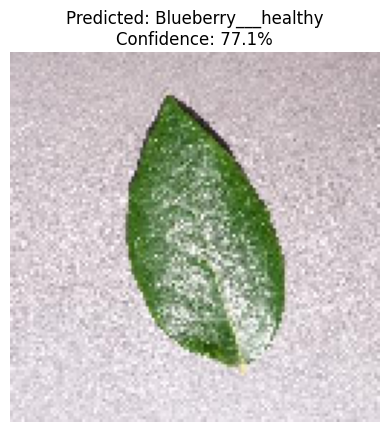

Disease : Blueberry___healthy
Confidence: 77.10%


In [ ]:
from tensorflow.keras.preprocessing import image as keras_image

def predict_leaf(img_path):
    img  = keras_image.load_img(img_path, target_size=(128, 128))
    arr  = keras_image.img_to_array(img) / 255.0
    arr  = np.expand_dims(arr, axis=0)
    pred = model.predict(arr)
    idx  = np.argmax(pred)

    plt.imshow(img)
    plt.axis('off')
    plt.title(
        f"Predicted: {class_names[idx]}\n"
        f"Confidence: {pred[0][idx]*100:.1f}%",
        fontsize=12
    )
    plt.show()
    print(f"Disease : {class_names[idx]}")
    print(f"Confidence: {pred[0][idx]*100:.2f}%")

# Usage — put any leaf image path here:
predict_leaf('/content/PlantVillage/plantvillage dataset/color/Blueberry___healthy/008c85d0-a954-4127-bd26-861dc8a1e6ff___RS_HL 2431.JPG')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


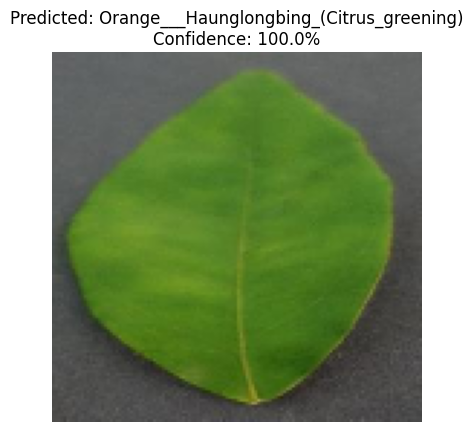

Disease : Orange___Haunglongbing_(Citrus_greening)
Confidence: 100.00%


In [ ]:
from tensorflow.keras.preprocessing import image as keras_image

def predict_leaf(img_path):
    img  = keras_image.load_img(img_path, target_size=(128, 128))
    arr  = keras_image.img_to_array(img) / 255.0
    arr  = np.expand_dims(arr, axis=0)
    pred = model.predict(arr)
    idx  = np.argmax(pred)

    plt.imshow(img)
    plt.axis('off')
    plt.title(
        f"Predicted: {class_names[idx]}\n"
        f"Confidence: {pred[0][idx]*100:.1f}%",
        fontsize=12
    )
    plt.show()
    print(f"Disease : {class_names[idx]}")
    print(f"Confidence: {pred[0][idx]*100:.2f}%")

# Usage — put any leaf image path here:
predict_leaf('/content/PlantVillage/plantvillage dataset/color/Orange___Haunglongbing_(Citrus_greening)/00045d08-898c-40df-ada6-e7579637a1f9___UF.Citrus_HLB_Lab 1690.JPG')

Saving Frogeye-Leaf-Spot-aka-Black-Rot-Botryosphaeria-on-Apple-Tree.jpg to Frogeye-Leaf-Spot-aka-Black-Rot-Botryosphaeria-on-Apple-Tree.jpg


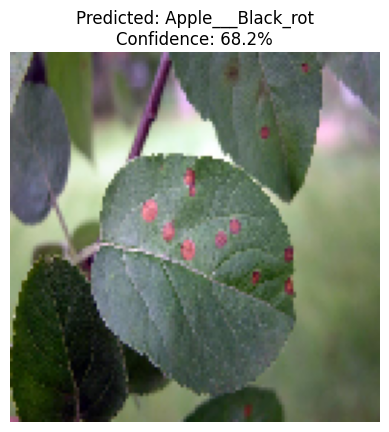

Disease   : Apple___Black_rot
Confidence: 68.21%


In [ ]:
from tensorflow.keras.preprocessing import image as keras_image
from google.colab import files

def predict_leaf(img_path):
    img  = keras_image.load_img(img_path, target_size=(128, 128))
    arr  = keras_image.img_to_array(img) / 255.0
    arr  = np.expand_dims(arr, axis=0)

    pred = model.predict(arr, verbose=0)
    idx  = np.argmax(pred)
    confidence = pred[0][idx]

    plt.imshow(img)
    plt.axis('off')
    plt.title(
        f"Predicted: {class_names[idx]}\n"
        f"Confidence: {confidence*100:.1f}%",
        fontsize=12
    )
    plt.show()

    print(f"Disease   : {class_names[idx]}")
    print(f"Confidence: {confidence*100:.2f}%")


# ✅ DEMO USAGE (replace old path line)
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

predict_leaf(img_path)